In [1]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# sklearn imports
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    roc_auc_score
)

In [3]:
# read csv
df = pd.read_csv("large_tot_df.csv")

In [68]:
df.head(5)

,Unnamed: 0,sentence,record_type,keyword,loss,wctc_loss,pred_strings
0,0,kúkù ŋgá kɛ̀cí ɛ́ɾáðɛ́ nɛ̀ rî,negative,àpɾí,633.209473,40.025875,bb<blk>bɒbbʷʷbbb<blk>ʷ<blk>ɒbʷɒɒɒʷʷʷ<blk>bbɹ<b...
1,1,láɾl̀à ðə́ɟíðɔ́ dìjɔ́ nd̪ɔ̀bà,negative,àpɾí,601.036743,39.749714,bbbbbbbbbbbbbbbbbɔbbbbbbb<blk>b<blk>b<blk>bbɒb...
2,2,ðɔ̀mɔ̀cɔ̀ ðápàt̪ɛ̀ àpɾíɲá ɛ̀ðɛ̀,close_negative,àpɾí,589.775330,39.951847,bbb<blk>bbbbbʎbbbʎʎʷbɒʎʎ<blk>bbbʷbɒʷbɒbɒbbʷɒbb...
3,3,t̪átɛ́ ùnɛ́ɾɛ́ újɛ̀l,negative,àpɾí,533.147278,39.834587,b<blk>bɹb<blk>ɹ<blk>bb<blk>bbbbbʷʷɒɒɒɒɑɒɒɒʎʷʷɒ...
4,4,kńnà àpɾí jɛ́ àɾɔ́ ðówɛ́ íðɔ̀,positive,àpɾí,525.720093,40.537830,b<blk><blk>ɹbb<blk>bbbʟbbbb<blk>b<blk>bbb<blk>...


In [72]:
df.loc[1]['pred_strings']

'bbbbbbbbbbbbbbbbbɔbbbbbbb<blk>b<blk>b<blk>bbɒbbbǂɑʷʜɒʷɒɒɒʷɑǂɒɒɒʷɒǂɒɒbʷɒɒʎbbbbb<blk>bbbbbbɒɒbɒbbbbbɒbɒɒɒɒʷʷbʷbbb<blk>bbbbb<blk>bbbbbbbbbbbbbbɒɒbbb<blk>b<blk>b<blk>bbbbbbɒbʎbɒʎʎb<blk>ʷʎʎbbbbɒbbbbbɒʎbʛʷʷʎʎɒɒbbʎɒbbbbbbbbbbbb<blk>b<blk><blk><blk>bb<blk><blk>b<blk>'

In [5]:
df["keyword"].value_counts()

keyword
àpɾí           120
ðɔ̀mɔ̀cɔ̀        120
lɛ́ŋgɛ́n         120
ŋɔ̀ɽíŋgɔ́       120
mùðù           120
ùɾnɔ̀           120
ðàŋàl          120
kə̀və̀lɛ̀ðɔ́     120
kàŋú           120
íŋgá_nɔ̀nà    120
Name: count, dtype: int64

## Keyword: "àpɾí"

In [78]:
# select keyword for dataframe
ap_kw_df = df[df["keyword"] == "àpɾí"]
ap_kw_df.shape

(120, 7)

In [79]:
# make z scored prediction column
y_pred = ap_kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [80]:
# map true values to respective binary values
y_true = ap_kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [81]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.0774
ROC AUC: 0.4300


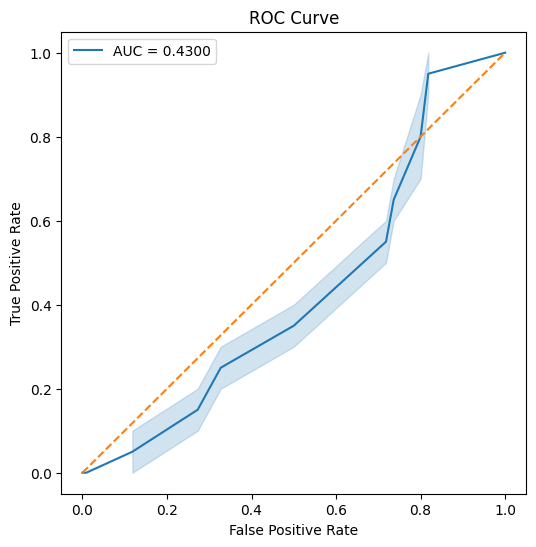

In [82]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

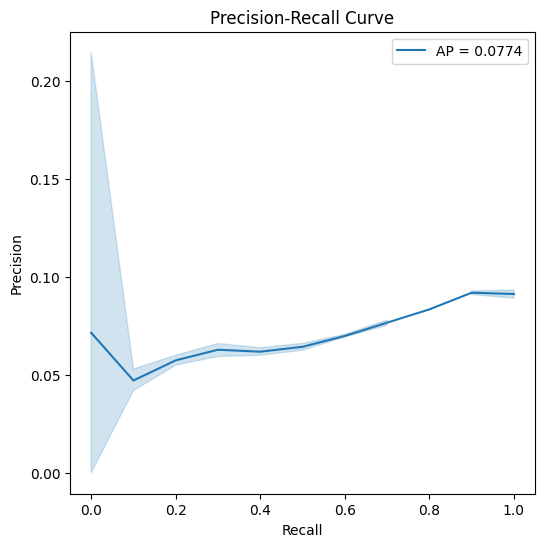

In [83]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "ðɔ̀mɔ̀cɔ̀"

In [14]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "ðɔ̀mɔ̀cɔ̀"]
kw_df.shape

(120, 7)

In [15]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [16]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [17]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1043
ROC AUC: 0.6000


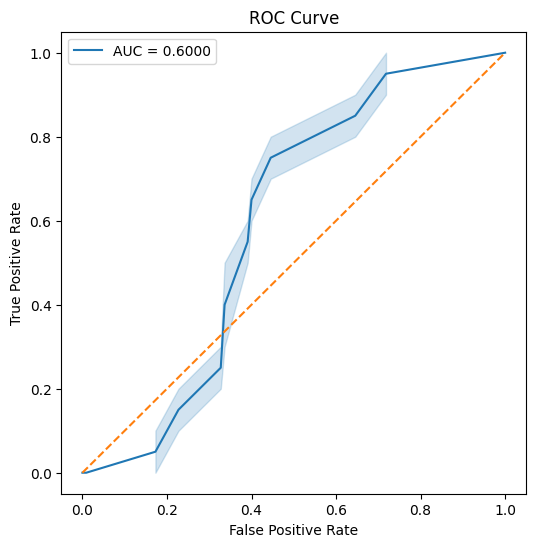

In [18]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

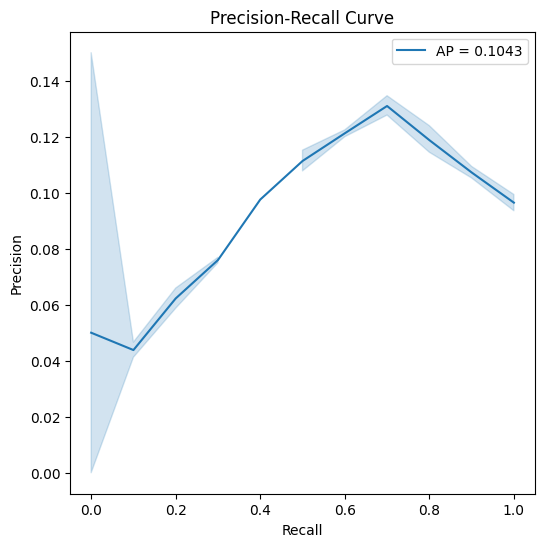

In [19]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "lɛ́ŋgɛ́n"

In [20]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "lɛ́ŋgɛ́n"]
kw_df.shape

(120, 7)

In [21]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [22]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [23]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.2119
ROC AUC: 0.6173


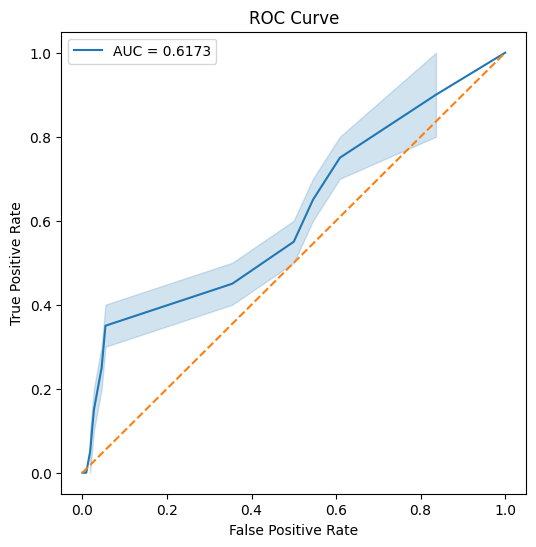

In [24]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

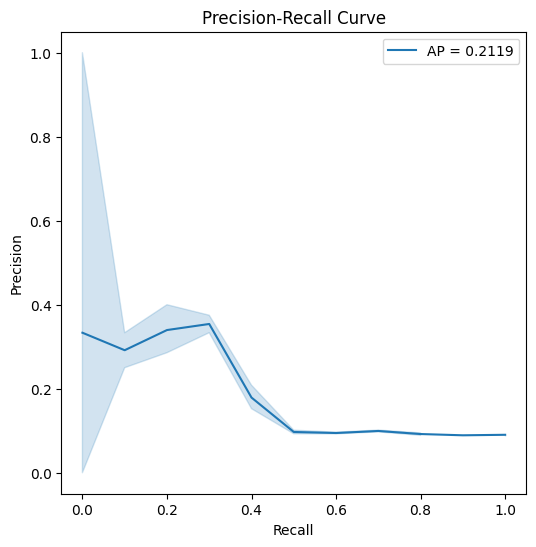

In [25]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "ŋɔ̀ɽíŋgɔ́"

In [26]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "ŋɔ̀ɽíŋgɔ́"]
kw_df.shape

(120, 7)

In [27]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [28]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [29]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1020
ROC AUC: 0.5155


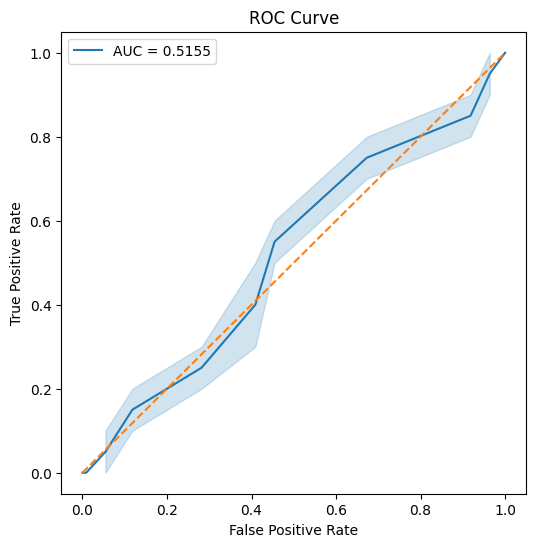

In [30]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

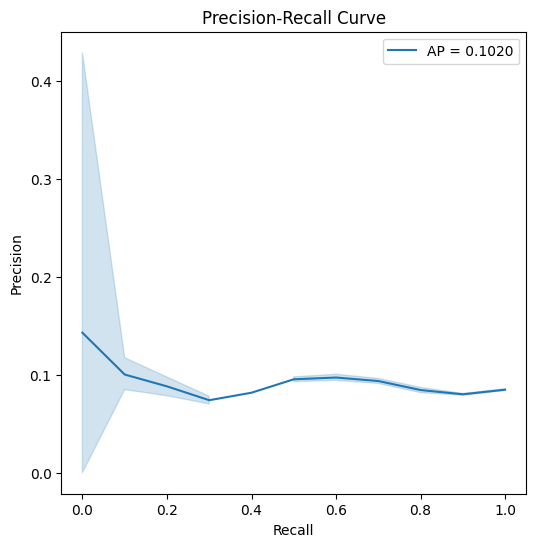

In [31]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "mùðù"

In [32]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "mùðù"]
kw_df.shape

(120, 7)

In [33]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [34]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [35]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1779
ROC AUC: 0.6055


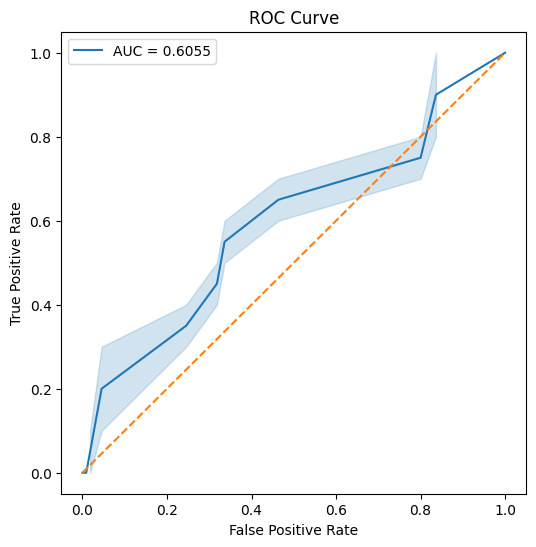

In [36]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

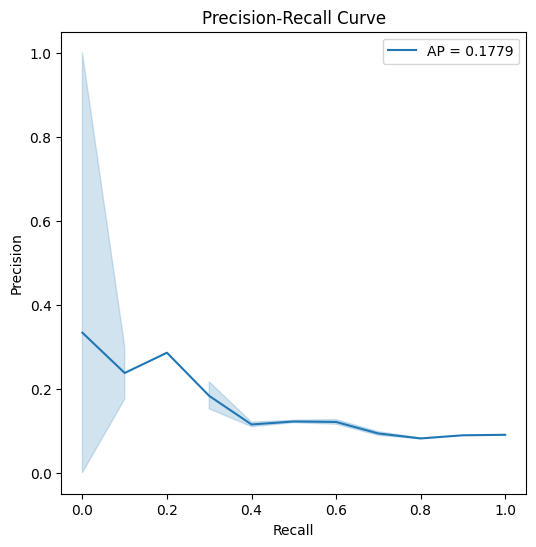

In [37]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "ùɾnɔ̀"

In [38]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "ùɾnɔ̀"]
kw_df.shape

(120, 7)

In [39]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [40]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [41]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.0743
ROC AUC: 0.4164


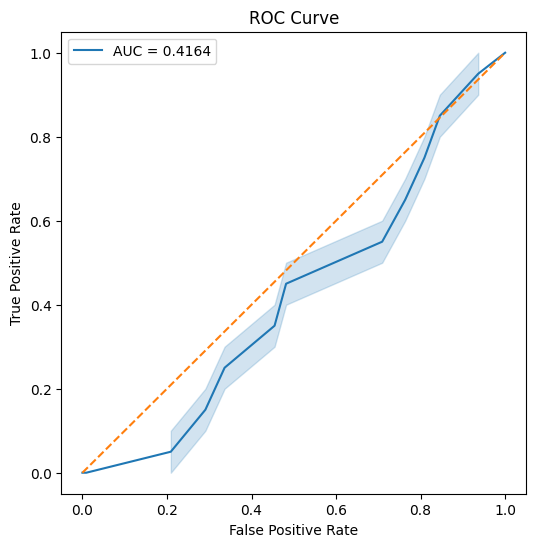

In [42]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

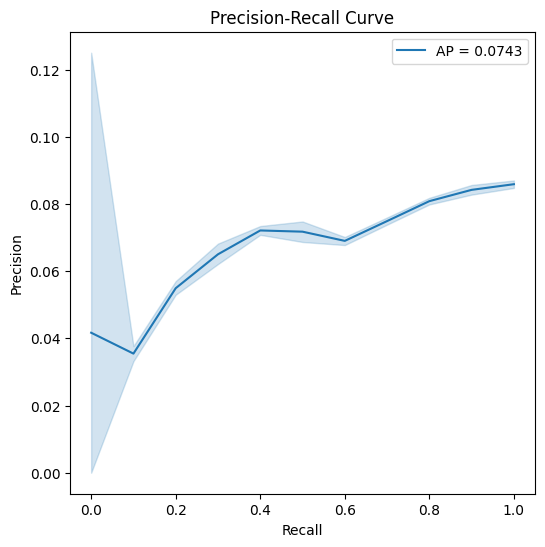

In [43]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "ðàŋàl"

In [44]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "ðàŋàl"]
kw_df.shape

(120, 7)

In [45]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [46]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [47]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1186
ROC AUC: 0.6236


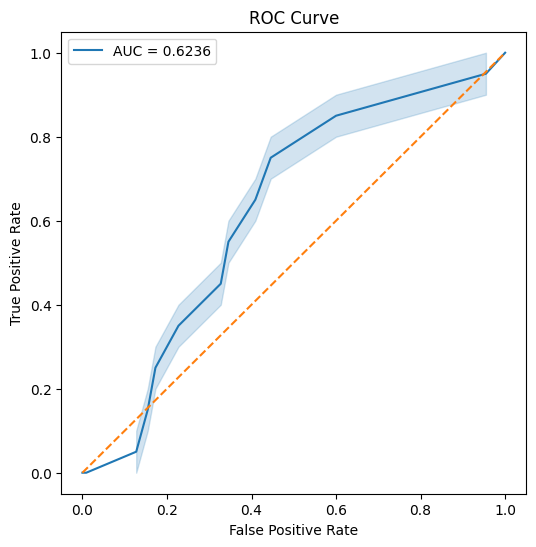

In [48]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

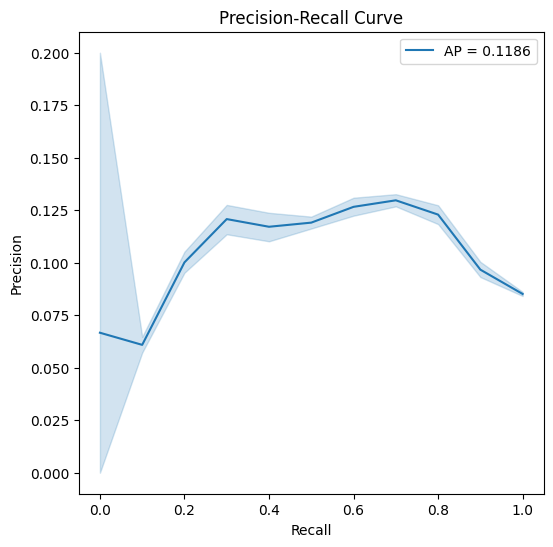

In [49]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "kə̀və̀lɛ̀ðɔ́"

In [50]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "kə̀və̀lɛ̀ðɔ́"]
kw_df.shape

(120, 7)

In [51]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [52]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [53]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1502
ROC AUC: 0.5245


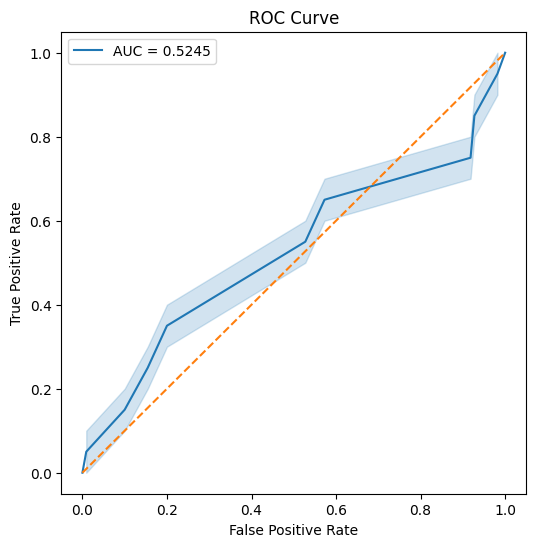

In [54]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

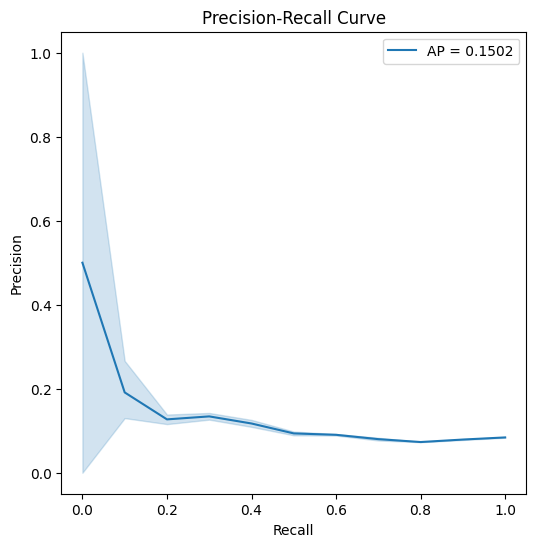

In [55]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "kàŋú"

In [56]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "kàŋú"]
kw_df.shape

(120, 7)

In [57]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [58]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [59]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1337
ROC AUC: 0.4800


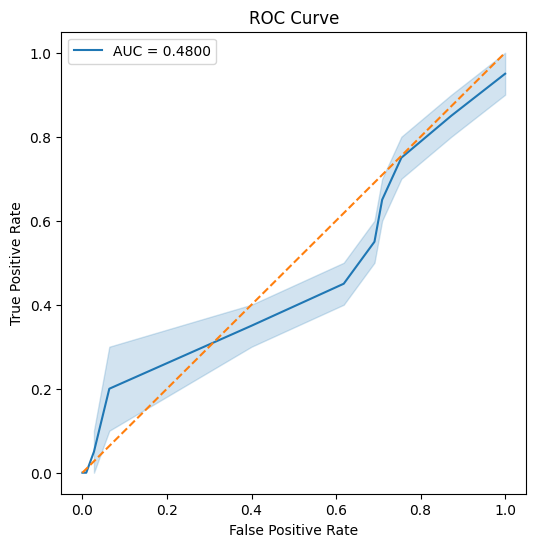

In [60]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

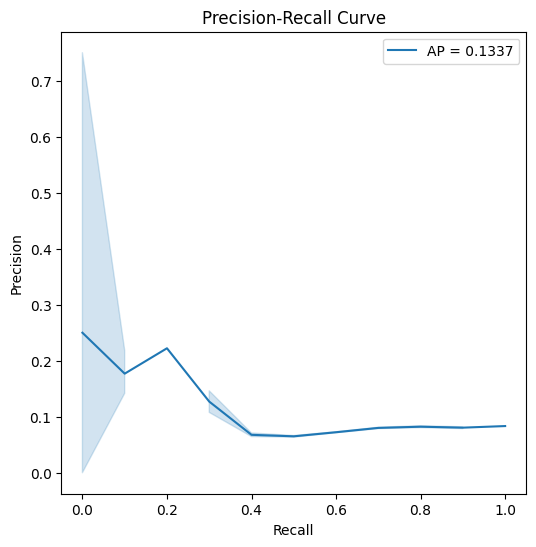

In [61]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "íŋgá_nɔ̀nà"

In [62]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "íŋgá_nɔ̀nà"]
kw_df.shape

(120, 7)

In [63]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [64]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [65]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1307
ROC AUC: 0.6600


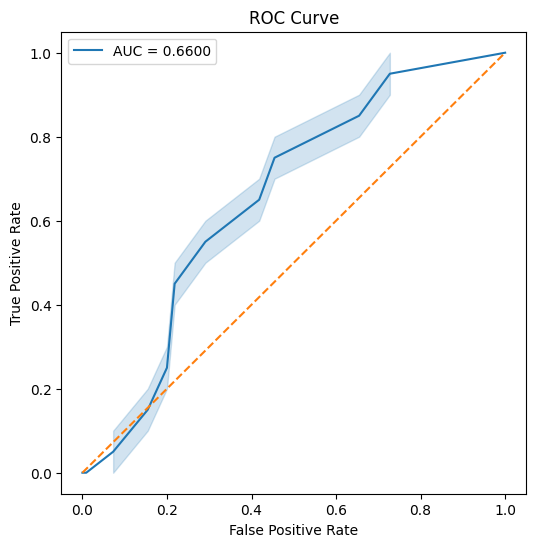

In [66]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

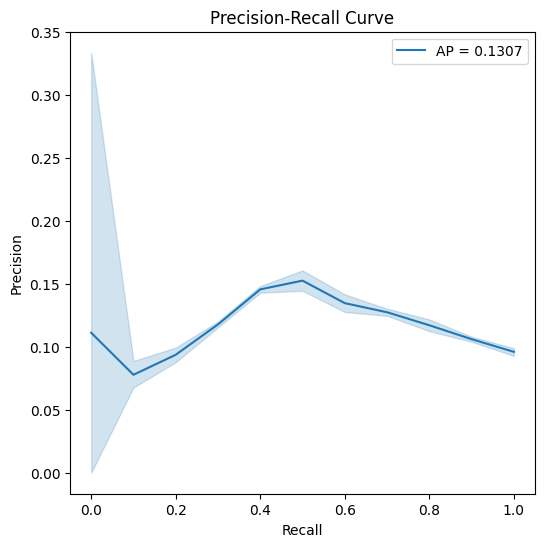

In [67]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

### Trying Normalized Losses with Min-Max Scaling

In [73]:
from sklearn.preprocessing import MinMaxScaler

In [74]:
#apri
losses = ap_kw_df["wctc_loss"].values.reshape(-1, 1)

scaler = MinMaxScaler()

normalized_losses = scaler.fit_transform(losses).flatten()

scores = 1 - normalized_losses

In [75]:
ap = average_precision_score(y_true, scores)

fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = roc_auc_score(y_true, scores)

precision, recall, _ = precision_recall_curve(y_true, scores)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1952
ROC AUC: 0.5455


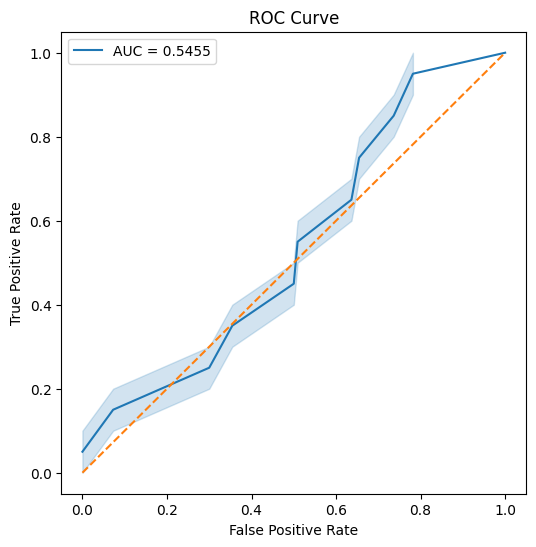

In [76]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

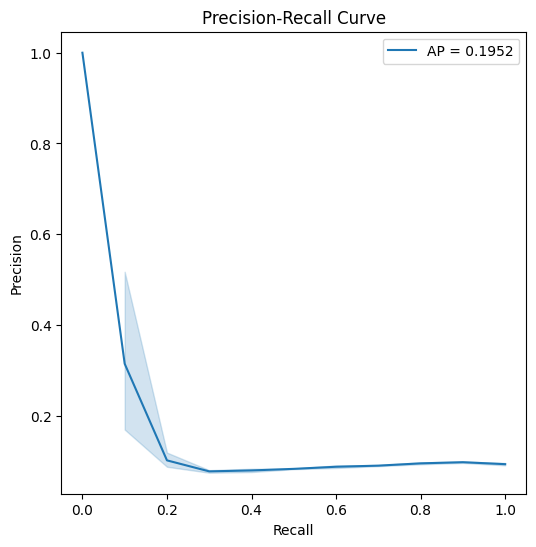

In [77]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()